## 遗传算法（GA）

遗传算法（Genetic Algorithm, GA）是一种模拟生物进化过程的随机优化算法。

它不直接去算出答案，而是维护一群候选解，让这些候选解像生物种群一样不断经历：

1. 选择，让更优秀的个体更有机会留下来。
2. 交叉：把两个个体的“基因”拼接组合，产生新个体。
3. 变异：随机修改一小部分基因，防止种群太早僵化。
4. 迭代进化：一代一代筛选和繁殖，直到找到足够好的解。

它特别适合搜索空间很大、很复杂的问题，同时难以直接求导或没有明确解析解的问题。例如组合优化当中的路径规划、排程、参数搜索等。

![豌豆家族](image2-1.png)


## 问题定义

对于一个优化问题，可以抽象为下面几个部分：

$$(\mathcal{S}, f, \phi)$$

其中，

- 解空间 $\mathcal{S}$ ：所有可行解的集合。

- 目标函数 $f$：用于评价一个解的好坏。

- 编码方式 $\phi$：把一个解表示成“染色体”的方式。

我们的目标是：

- 若是最大化问题，则希望找到

$$
x^* \in \mathcal{S}, \quad \text{s.t. } f(x^*) \ge f(x),\; \forall x \in \mathcal{S}
$$

- 若是最小化问题，则希望找到

$$
x^* \in \mathcal{S}, \quad \text{s.t. } f(x^*) \le f(x),\; \forall x \in \mathcal{S}
$$

传算法的想法不是直接去追这个 $x^*$，而是先造出一批候选解：

$$
P^{(0)} = \{x_1, x_2, \dots, x_N\}
$$

这里的 $P^{(0)}$ 就是**初始种群**。之后我们不断让这个种群进化，希望它越来越优。

# 核心机制

遗传算法的核心在于一句话：

> **让好的解更容易留下来，并让不同解之间不断重组，从而逐渐逼近更优解。**

一个标准的遗传算法通常包含以下几个步骤。

## 1. 编码（Encoding）

首先要决定：一个解该如何表示。

常见编码方式有：

- **二进制编码**：例如 `10110110`
- **实数编码**：例如 $[1.24, -0.7, 3.19]$
- **排列编码**：例如旅行商问题中的访问顺序 `[3,1,5,2,4]`

编码方式决定了后续交叉、变异怎么做。

## 2. 适应度评估（Fitness Evaluation）

每个个体都要打分。这个分数称为**适应度**（Fitness）。

如果原问题是最大化问题，可以直接令：

$$
\text{Fitness}(x) = f(x)
$$

如果原问题是最小化问题，通常需要做一个变换，例如：

$$
\text{Fitness}(x) = \frac{1}{1 + f(x)}
$$

这样目标函数越小，适应度越大。

## 3. 选择（Selection）

选择的目标是：

- 给高适应度个体更高的繁殖概率
- 但也不要把低适应度个体全部立刻杀光

经典做法包括：

- 轮盘赌选择（Roulette Wheel Selection）
- 锦标赛选择（Tournament Selection）
- 排名选择（Rank Selection）

例如轮盘赌选择中，第 $i$ 个个体被选中的概率为：

$$
p_i = \frac{F_i}{\sum_{j=1}^{N} F_j}
$$

其中 $F_i$ 表示个体 $i$ 的适应度。

## 4. 交叉（Crossover）

交叉相当于“两个父母生孩子”。

假设两个父代染色体是：

```text
父代1：110|0101
父代2：001|1110
```

若在中间切开并交换后半段，则可能得到：

```text
子代1：1101110
子代2：0010101
```

交叉的意义在于：1.让不同个体的优良片段有机会组合到一起；2.比“纯随机乱试”更高效地探索解空间

常见方式有：

- 单点交叉
- 双点交叉
- 均匀交叉
- 针对排列编码的 PMX / OX / CX 等

## 5. 变异（Mutation）

变异是对个体进行小概率随机修改。

例如二进制编码中：

```text
原染色体：101101
变异后：101001
```

变异的作用很重要，它能够

- 防止种群过早陷入单一结构
- 提供新的基因片段
- 帮助算法跳出局部最优

如果变异率太小，种群容易早熟；如果太大，算法又会退化成随机搜索。

## 6. 生存更新（Replacement）

产生新个体后，要决定谁留下进入下一代。

常见策略有：

- 父代全部替换为子代
- 父代与子代合并后选最优的 $N$ 个
- 精英保留（Elitism）：强制保留当前最优个体，防止好解丢失



# 人话

我们现在有一个目标：培育出一只跑得最快的机器狗。你当然可以一个个试，但很多问题的方案空间太大了，大到你试到下辈子都试不完。遗传算法就是一套模拟大自然繁衍进化的流程，通过一代代的筛选，最终把最优良的基因（图纸）留下来。

![外教](image2-2.png)


**第一步：初始化种群（女娲捏人）**

游戏刚开始，我们不知道什么样的机器狗跑得快，所以我们让电脑随机生成 100 份不同的机器狗设计图纸（有长腿的、短腿的、三个轮子的、带翅膀的）。这 100 份随机生成的图纸，就叫做初代种群；每一份图纸就是一个个体；图纸上的零件参数，就是染色体/基因。

**第二步：评估适应度（期末考试）**

是骡子是马拉出来溜溜。把这 100 只随机造出来的机器狗放到跑道上跑一跑，看看谁跑得最远、最快。跑得越快的，得分越高；跑两步就散架的，得分垫底。

这里的得分，就叫做适应度（Fitness）。适应度函数是我们评价一个解好坏的唯一标准。

**第三步：选择（优胜劣汰）**

考试成绩出来了，大自然要开始淘汰弱者了。跑得慢的机器狗图纸直接被销毁；跑得快的机器狗不仅活了下来，还获得了更多的交配权。

这个过程叫做选择（Selection）。常用的方法是“轮盘赌”，即适应度越高的个体，被选中繁衍后代的概率就越大。

*机器狗也会交配吗？仿生人会梦见电子羊吗？*

**第四步：交叉/繁殖（优势互补）**

存活下来的优秀机器狗开始生小狗。比如，1号狗（腿长但身体重）和 2号狗（腿短但身体轻）看对眼了，它们会把各自图纸撕一半拼在一起，生出一只新狗（可能继承了“腿长+身体轻”的完美基因，也可能倒霉地继承了“腿短+身体重”的废柴基因）。

这叫做交叉（Crossover）。通过交换父母的基因片段，算法能够在已有的好方案基础上，探索出更好的新方案。

**第五步：变异（基因突变）**

在生小狗的过程中，偶尔会发生一点点小意外（概率极低，比如 1%）。比如某只小狗的图纸上，某个零件突然发生变异，长出了一个火箭推进器，这种突变有时候会带来意想不到的绝佳效果。

这叫做变异（Mutation）。变异非常重要，它可以防止我们的机器狗家族陷入“近亲繁殖”的瓶颈（即陷入局部最优解），保持物种的多样性。

**第六步：循环迭代**

现在，第一代老狗光荣退休，新繁衍出的 100 只小狗组成了第二代。我们重复第二步到第五步（考试、淘汰、繁衍、变异），不断循环。随着代数增加（比如繁衍了 500 代），留下来的机器狗简直就是奔跑神兽。

当种群进化到我们设定的最大代数（Max Generations），或者连续几代最快速度都不再提升时，算法终止。此时排名第一的那只狗，就是我们找到的最优解。

![外教](image2-3.png)

它不像贪心算法那样只盯着眼前最好的一步，也不像暴力搜索那样穷举全部可能; 它更像是一种带有试错、继承、随机扰动的大规模群体搜索。



# 基本流程

一个标准遗传算法可以写成下面的流程：

## 初始化

随机生成大小为 $N$ 的初始种群：

$$
P^{(0)} = \{x_1, x_2, \dots, x_N\}
$$

## 对每一代重复以下步骤

### 第一步：计算适应度

对种群中每个个体 $x_i$，计算：

$$
F_i = \text{Fitness}(x_i)
$$

### 第二步：选择父代

根据适应度，从当前种群中抽取若干个体作为父代。

### 第三步：交叉产生子代

对父代两两配对，以概率 $p_c$ 执行交叉。

### 第四步：变异

对子代中的每个基因位，以概率 $p_m$ 执行变异。

### 第五步：生成下一代

利用替换策略形成新种群 $P^{(t+1)}$。

### 第六步：判断是否终止

若满足以下任一条件，则停止：

- 达到最大迭代代数
- 最优适应度已满足要求
- 连续若干代没有明显提升



# 案例1

下面给出一个极简版遗传算法示例，用来最大化函数：

$$
f(x) = x \sin(10\pi x) + 2
$$


In [1]:
import random
import math

# 目标函数

def f(x):
    return x * math.sin(10 * math.pi * x) + 2

# 初始化种群

def init_population(size, left=-1, right=2):
    return [random.uniform(left, right) for _ in range(size)]

# 适应度（这里直接用目标函数值）

def fitness(population):
    return [f(x) for x in population]

# 轮盘赌选择

def select(population, fit_vals):
    total = sum(fit_vals)
    probs = [v / total for v in fit_vals]
    chosen = random.choices(population, weights=probs, k=len(population))
    return chosen

# 实数交叉

def crossover(p1, p2, pc=0.8):
    if random.random() < pc:
        alpha = random.random()
        c1 = alpha * p1 + (1 - alpha) * p2
        c2 = alpha * p2 + (1 - alpha) * p1
        return c1, c2
    return p1, p2

# 实数变异

def mutate(x, pm=0.1, sigma=0.1, left=-1, right=2):
    if random.random() < pm:
        x += random.gauss(0, sigma)
    return max(left, min(right, x))

# 主程序

def ga(pop_size=20, generations=50):
    pop = init_population(pop_size)
    best_x = None
    best_y = float('-inf')

    for _ in range(generations):
        fit_vals = fitness(pop)

        for x, y in zip(pop, fit_vals):
            if y > best_y:
                best_x, best_y = x, y

        parents = select(pop, fit_vals)
        new_pop = []

        for i in range(0, pop_size, 2):
            p1 = parents[i]
            p2 = parents[(i + 1) % pop_size]
            c1, c2 = crossover(p1, p2)
            c1 = mutate(c1)
            c2 = mutate(c2)
            new_pop.extend([c1, c2])

        pop = new_pop[:pop_size]

    return best_x, best_y

best_x, best_y = ga()
print('best_x =', best_x)
print('best_y =', best_y)

best_x = 1.2543459047446914
best_y = 3.2426731666554263


这个版本非常简化，但已经包含了遗传算法最核心的四件事：

- 初始化种群
- 适应度评估
- 选择
- 交叉与变异


# 案例2

某生鲜企业需要从一个配送中心出发，用最多 4 辆冷链车给 12 家门店送货。每家门店都有：

- 固定需求量
- 可接货时间窗
- 固定卸货服务时间
- 
每辆车都有最大载重限制，所有车辆都必须从配送中心出发，最终回到配送中心。

目标是在尽量满足约束的前提下，让总配送距离尽可能短。

## 为什么适合用遗传算法

这个题的难点不只在“怎么走”，还在：

- 客户怎么分配给不同车辆
- 每辆车内部的访问顺序怎么排
- 同时还要考虑容量约束和时间窗约束

这类问题属于典型组合优化问题，结构复杂，规模一大就很难枚举，因此非常适合用遗传算法做全局搜索。


## 核心建模思路

这里采用一种很常见的套路：

1. 染色体只编码“客户访问排列”
2. 解码器再把这个排列切分成多条车辆路径
3. 用总距离加罚函数来评价方案

总代价可以理解为：

- 总路程
- 加上容量超限罚项
- 加上时间窗迟到罚项
- 加上车辆数超限罚项

这样，遗传算法就能在一个统一的代价函数上做搜索。

最优染色体: [1, 3, 4, 7, 9, 10, 5, 2, 6, 11, 12, 8]
最优总代价: 546.16
最优路径如下：
车辆 1: 0 -> 1 -> 3 -> 4 -> 0
  载重: 20, 路程: 125.73
车辆 2: 0 -> 7 -> 9 -> 10 -> 0
  载重: 20, 路程: 155.68
车辆 3: 0 -> 5 -> 2 -> 6 -> 0
  载重: 19, 路程: 156.59
车辆 4: 0 -> 11 -> 12 -> 8 -> 0
  载重: 20, 路程: 108.16
总距离: 546.16


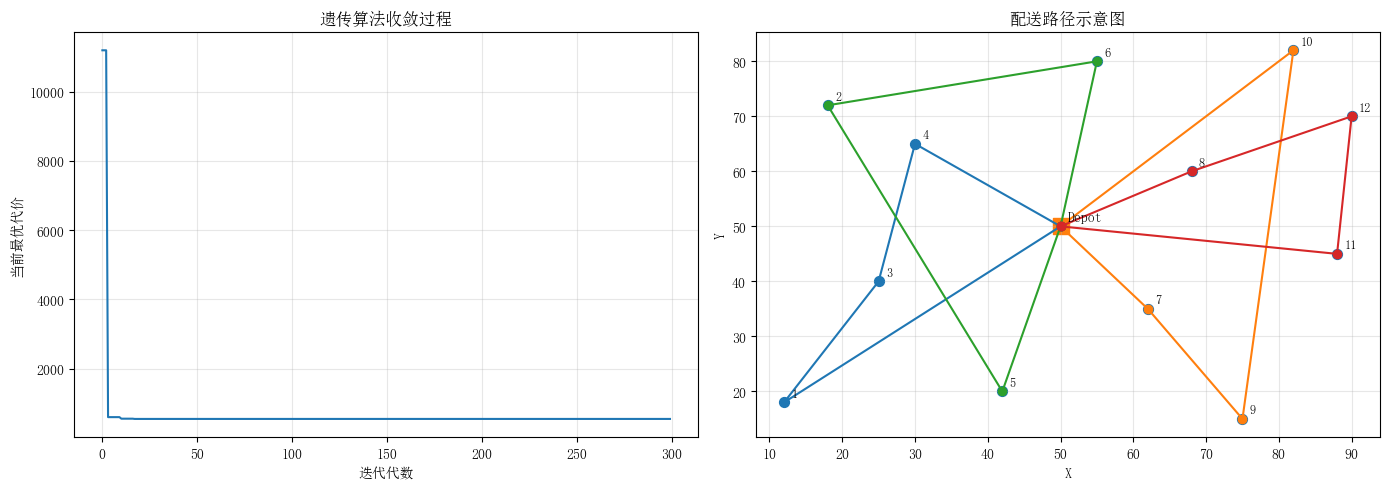

In [8]:
import random
import math
from dataclasses import dataclass
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimSun'] 
plt.rcParams['axes.unicode_minus'] = False

@dataclass
class Customer:
    idx: int
    x: float
    y: float
    demand: int
    ready: float
    due: float
    service: float


raw_data = [
    (0,   50, 50,   0,      0,   999,   0),
    (1,   12, 18,   8,      0,    80,  10),
    (2,   18, 72,   6,     15,   120,   8),
    (3,   25, 40,   7,     20,   100,  10),
    (4,   30, 65,   5,     40,   140,   6),
    (5,   42, 20,   9,      0,    90,  12),
    (6,   55, 80,   4,     60,   160,   8),
    (7,   62, 35,   8,     30,   110,   7),
    (8,   68, 60,   6,     50,   150,   9),
    (9,   75, 15,   7,      0,    95,  10),
    (10,  82, 82,   5,     70,   170,   8),
    (11,  88, 45,   6,     20,   130,  10),
    (12,  90, 70,   8,     80,   180,  12),
]

customers = [Customer(*row) for row in raw_data]
N = len(customers)
CUSTOMER_IDS = list(range(1, N))

VEHICLE_CAPACITY = 20
MAX_VEHICLES = 4


def euclid(a, b):
    return math.hypot(a.x - b.x, a.y - b.y)


def build_distance_matrix(customers):
    n = len(customers)
    dist = [[0.0] * n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            dist[i][j] = euclid(customers[i], customers[j])
    return dist


dist = build_distance_matrix(customers)


def decode_routes(chromosome, customers, dist, capacity, max_vehicles):
    routes = []
    current_route = []
    current_load = 0
    current_time = 0.0
    last_node = 0

    for cust_idx in chromosome:
        c = customers[cust_idx]
        arrival = current_time + dist[last_node][cust_idx]
        start_service = max(arrival, c.ready)
        finish_service = start_service + c.service

        feasible = True
        if current_load + c.demand > capacity:
            feasible = False
        if finish_service > c.due:
            feasible = False

        if feasible:
            current_route.append(cust_idx)
            current_load += c.demand
            current_time = finish_service
            last_node = cust_idx
        else:
            if current_route:
                routes.append(current_route)
            current_route = [cust_idx]
            current_load = c.demand
            arrival = dist[0][cust_idx]
            start_service = max(arrival, c.ready)
            finish_service = start_service + c.service
            current_time = finish_service
            last_node = cust_idx

    if current_route:
        routes.append(current_route)

    if len(routes) > max_vehicles:
        merged = routes[:max_vehicles - 1]
        tail = []
        for r in routes[max_vehicles - 1:]:
            tail.extend(r)
        merged.append(tail)
        routes = merged

    return routes


def evaluate(chromosome, customers, dist, capacity, max_vehicles,
             cap_penalty=1000.0, tw_penalty=50.0, vehicle_penalty=500.0):
    routes = decode_routes(chromosome, customers, dist, capacity, max_vehicles)

    total_distance = 0.0
    total_cap_violation = 0.0
    total_tw_violation = 0.0
    vehicle_violation = max(0, len(routes) - max_vehicles)

    for route in routes:
        load = 0
        time = 0.0
        last = 0

        for cust_idx in route:
            c = customers[cust_idx]
            total_distance += dist[last][cust_idx]
            arrival = time + dist[last][cust_idx]
            late = max(0.0, arrival - c.due)
            total_tw_violation += late
            time = max(arrival, c.ready) + c.service
            load += c.demand
            last = cust_idx

        total_distance += dist[last][0]
        total_cap_violation += max(0, load - capacity)

    cost = (total_distance
            + cap_penalty * total_cap_violation
            + tw_penalty * total_tw_violation
            + vehicle_penalty * vehicle_violation)

    return cost, routes


def tournament_selection(population, scores, k=3):
    ids = random.sample(range(len(population)), k)
    best_id = min(ids, key=lambda i: scores[i])
    return population[best_id][:]


def ordered_crossover(parent1, parent2):
    n = len(parent1)
    a, b = sorted(random.sample(range(n), 2))
    child = [None] * n
    child[a:b + 1] = parent1[a:b + 1]
    fill = [g for g in parent2 if g not in child]
    ptr = 0
    for i in range(n):
        if child[i] is None:
            child[i] = fill[ptr]
            ptr += 1
    return child


def swap_mutation(chromosome, pm=0.2):
    c = chromosome[:]
    if random.random() < pm:
        i, j = random.sample(range(len(c)), 2)
        c[i], c[j] = c[j], c[i]
    return c


def inversion_mutation(chromosome, pm=0.2):
    c = chromosome[:]
    if random.random() < pm:
        i, j = sorted(random.sample(range(len(c)), 2))
        c[i:j + 1] = reversed(c[i:j + 1])
    return c


def genetic_algorithm(customers,
                      capacity=20,
                      max_vehicles=4,
                      pop_size=80,
                      generations=200,
                      pc=0.9,
                      pm=0.3,
                      elite_size=4,
                      seed=42):
    random.seed(seed)
    population = [random.sample(CUSTOMER_IDS, len(CUSTOMER_IDS)) for _ in range(pop_size)]

    best_cost = float('inf')
    best_chromosome = None
    history = []

    for _ in range(generations):
        scores = []
        for chrom in population:
            cost, _ = evaluate(chrom, customers, dist, capacity, max_vehicles)
            scores.append(cost)
            if cost < best_cost:
                best_cost = cost
                best_chromosome = chrom[:]

        history.append(best_cost)

        elite_ids = sorted(range(pop_size), key=lambda i: scores[i])[:elite_size]
        new_population = [population[i][:] for i in elite_ids]

        while len(new_population) < pop_size:
            p1 = tournament_selection(population, scores)
            p2 = tournament_selection(population, scores)

            if random.random() < pc:
                c1 = ordered_crossover(p1, p2)
                c2 = ordered_crossover(p2, p1)
            else:
                c1, c2 = p1[:], p2[:]

            c1 = inversion_mutation(swap_mutation(c1, pm), pm)
            c2 = inversion_mutation(swap_mutation(c2, pm), pm)
            new_population.extend([c1, c2])

        population = new_population[:pop_size]

    final_cost, final_routes = evaluate(best_chromosome, customers, dist, capacity, max_vehicles)
    return best_chromosome, final_routes, final_cost, history


def print_solution(routes, customers, dist):
    total_distance = 0.0
    print('最优路径如下：')

    for r_id, route in enumerate(routes, start=1):
        load = 0
        time = 0.0
        last = 0
        route_dist = 0.0
        path = [0]

        for cust_idx in route:
            c = customers[cust_idx]
            route_dist += dist[last][cust_idx]
            arrival = time + dist[last][cust_idx]
            time = max(arrival, c.ready) + c.service
            load += c.demand
            last = cust_idx
            path.append(cust_idx)

        route_dist += dist[last][0]
        path.append(0)
        total_distance += route_dist

        print(f"车辆 {r_id}: {' -> '.join(map(str, path))}")
        print(f'  载重: {load}, 路程: {route_dist:.2f}')

    print(f'总距离: {total_distance:.2f}')


def plot_result(customers, routes, history):
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history)
    plt.xlabel('迭代代数')
    plt.ylabel('当前最优代价')
    plt.title('遗传算法收敛过程')
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    xs = [c.x for c in customers]
    ys = [c.y for c in customers]
    plt.scatter(xs[1:], ys[1:], s=50)
    plt.scatter(xs[0], ys[0], s=120, marker='s')
    plt.text(customers[0].x + 1, customers[0].y + 1, 'Depot')

    for c in customers[1:]:
        plt.text(c.x + 1, c.y + 1, str(c.idx), fontsize=9)

    for route in routes:
        full_route = [0] + route + [0]
        rx = [customers[i].x for i in full_route]
        ry = [customers[i].y for i in full_route]
        plt.plot(rx, ry, marker='o')

    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('配送路径示意图')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    best_chromosome, best_routes, best_cost, history = genetic_algorithm(
        customers,
        capacity=VEHICLE_CAPACITY,
        max_vehicles=MAX_VEHICLES,
        pop_size=100,
        generations=300,
        pc=0.9,
        pm=0.25,
        elite_size=6,
        seed=42
    )

    print('最优染色体:', best_chromosome)
    print(f'最优总代价: {best_cost:.2f}')
    print_solution(best_routes, customers, dist)
    plot_result(customers, best_routes, history)

希望读者能够理解，

1. 染色体设计不是随便写的，而是跟问题结构绑定；
2. 复杂约束问题通常要靠解码器和罚函数来处理；
3. 遗传算法真正擅长的是大规模组合搜索，而不是求一个漂亮解析解。